Environment name: `r_env_corr`

# 0. - Imports and paths

In [24]:
setwd(dir = "/disk2/user/gabgam/the_project/5_integration_and_correlation/")

In [25]:
suppressMessages(suppressWarnings(source("./utils/source_satac.R")))
library(biovizBase)

In [26]:
PATH_TO_sATAC_DATA_FOLDER <- "../data/spatial_atac/"
PATH_sATAC_PREPROCESSING_OUTPUT <- "output/sATAC_preprocessing/"
PATH_TO_FIGURES <- "figures/sATAC_preprocessing/"

SELECTED_sATAC_SAMPLE <- "220327_C1"

In [27]:
VISIUM_SAMPLE_NAME <- "FFPE"
PATH_TO_VISIUM_PROCESSED_FOLDER <- "output/Visium_preprocessing/"

PATH_TO_VISIUM_SAMPLE <- "../data/visium_ffpe/output_n_suppl_files/Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"

PATH_TO_VISIUM_ORIGINAL_SPOTFILE <- "../data/visium_ffpe/output_n_suppl_files/spatial/tissue_positions_list.csv"
PATH_TO_NECROSIS_SPOTS <- "../data/visium_ffpe/output_n_suppl_files/spatial/Visium_FFPE_selected_necrosis_spots_v2.csv"
# PATH_TO_VISIUM_MOD_SPOTFILE <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv"
PATH_TO_VISIUM_MOD_SPOTFILE <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv"
PATH_TO_VISIUM_CORRECTED_SPOTFILE <- "output/Visium_preprocessing/FFPE_correct_tissue_positions_list.csv"


PATH_TO_VISIUM_HIGH_RES_IMAGE <- "../data/visium_ffpe/output_n_suppl_files/spatial/tissue_hires_image.png"
PATH_TO_VISIUM_JSON <- "../data/visium_ffpe/output_n_suppl_files/spatial/scalefactors_json.json"

---
# 1. - Creating the initial Object

Remeber to change the names of the files inside the scRNA-seq folder.

Downloaded from: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE176078

```sh
wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176078/suppl/GSE176078%5FWu%5Fetal%5F2021%5FBRCA%5FscRNASeq%2Etar%2Egz
```

And remember to change the names of the files:
```sh
mv count_matrix_barcodes.tsv barcodes.tsv
mv count_matrix_genes.tsv genes.tsv
mv count_matrix_sparse.mtx matrix.mtx
```

In [28]:
# compare sATAC with scRNA-seq
## scRNA-seq atlas of BRCA obtained from https://www.nature.com/articles/s41588-021-00911-1
meta_sc <- read.csv("../data/Wu_etal_2021_BRCA_scRNASeq/metadata.csv", row.names = 1)
mtx <- Read10X("../data/Wu_etal_2021_BRCA_scRNASeq/", gene.column = 1)

In [29]:
# preprocess single cell data
sc_obj <- CreateSeuratObject(mtx, meta.data = meta_sc) %>%
  NormalizeData() %>%
  FindVariableFeatures() %>%
  ScaleData()


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



In [30]:
# satac_selected <- readRDS(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "final_preprocessing_sATAC_selected_", SELECTED_sATAC_SAMPLE, ".rds"))
# visium <- readRDS(paste0(PATH_TO_VISIUM_PROCESSED_FOLDER, "final_preprocessing_VISIUM_selected_", SELECTED_sATAC_SAMPLE, ".rds"))

In [31]:
satac_selected <- readRDS(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "final_preprocessing_sATAC_selected_", SELECTED_sATAC_SAMPLE, "_v2.rds"))
visium <- readRDS(paste0(PATH_TO_VISIUM_PROCESSED_FOLDER, "final_preprocessing_VISIUM_selected_", SELECTED_sATAC_SAMPLE, "_v2.rds"))

# For the ST sample

In [32]:
names(visium@meta.data)

[1] "orig.ident"          "nCount_RNA"          "nFeature_RNA"       
 [4] "id"                  "labels"              "RNA_snn_res.0.6"    
 [7] "seurat_clusters"     "kmeans_6"            "nCount_RNA_dca"     
[10] "nFeature_RNA_dca"    "RNA_dca_snn_res.0.6" "kmeans_6_dca"

In [33]:
# label transfer using the original authors' classification of cell types
transfer.anchors <- FindTransferAnchors(reference = sc_obj, 
                                        query = visium, 
                                        features = VariableFeatures(sc_obj), 
                                        reference.assay = "RNA", 
                                        query.assay = "RNA_dca", 
                                        reduction = "cca")


Warning message:
"475 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 1525 features."


Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 8920 anchors



In [34]:
unique(sc_obj$celltype_major)

[1] "Endothelial"       "CAFs"              "PVL"              
[4] "B-cells"           "T-cells"           "Myeloid"          
[7] "Normal Epithelial" "Plasmablasts"      "Cancer Epithelial"

In [35]:
celltype.predictions <- TransferData(anchorset = transfer.anchors, 
                                     refdata = sc_obj$celltype_major, 
                                     weight.reduction = visium[["pca"]],
                                     dims = 1:15)

visium <- AddMetaData(visium, metadata = celltype.predictions)

Finding integration vectors

Finding integration vector weights



Predicting cell labels



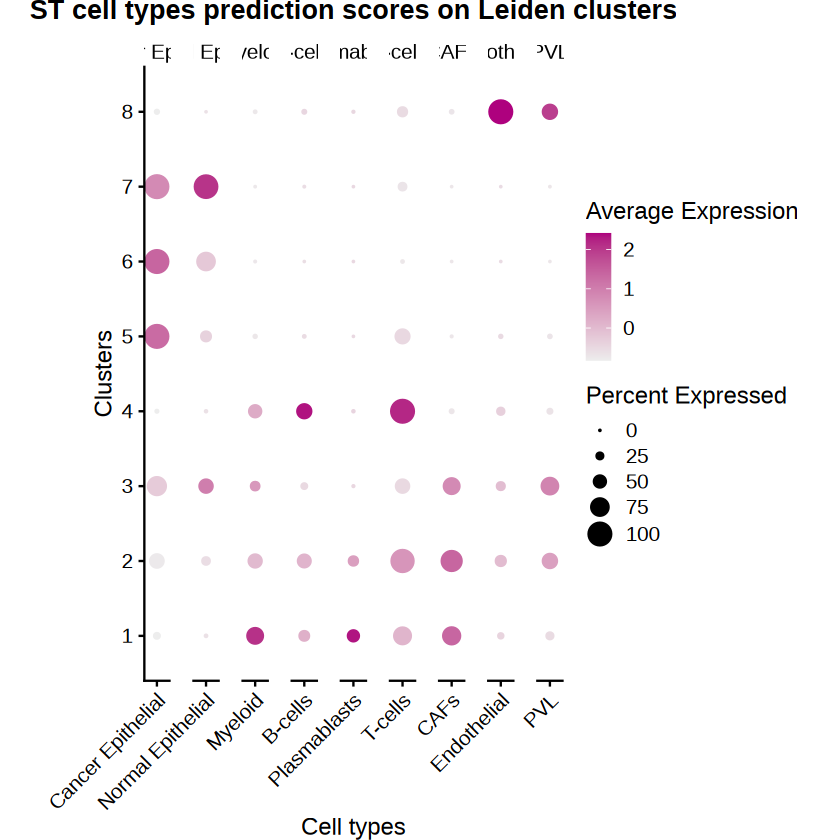

In [ ]:

# plot prediction scores as an indication of the type of cells found in the sATAC clusters 
# prediction_scores <- paste0("prediction.score.", levels(as.factor(sc_obj$celltype_major))) # original way

# new adapted way
desired_order <- c(
  "Cancer Epithelial", "Normal Epithelial", "Myeloid",
  "B-cells", "Plasmablasts", "T-cells", "CAFs",
  "Endothelial", "PVL"
)

# Clean names for lookup and plotting
clean_names <- make.names(desired_order)  # Convert to column format (dots instead of spaces/dashes)
prediction_features <- paste0("prediction.score.", clean_names)
names(prediction_features) <- desired_order  # Set pretty labels

# Now plot
DotPlot(visium, features = prediction_features, cols = c("gray93", "#AE017E")) +
  scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
  scale_y_discrete(name = "Clusters") +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.margin = margin(0, 1, 0, 2, "cm")  # bottom margin extended
  ) +
  ggtitle("ST cell type prediction scores on Leiden clusters")
ggsave("dotplot_predictions_leiden_clusters_visium.png", width = 8, height = 5, units = "in", dpi = 300)

Correcting input names for data and adapting the order for plotting purposes.

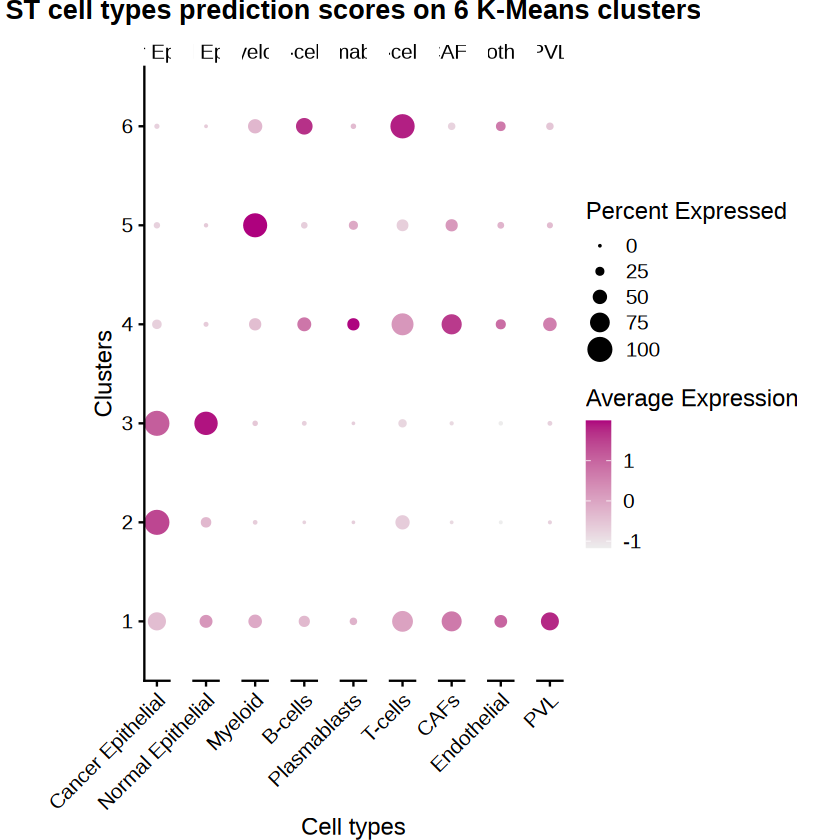

In [ ]:
# Now plot
DotPlot(visium, features = prediction_features, group.by = "kmeans_6", cols = c("gray93", "#AE017E")) +
  scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
  scale_y_discrete(name = "Clusters") +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.margin = margin(0, 1, 0, 2, "cm")  # bottom margin extended
  ) +
  ggtitle("ST cell type prediction scores on 6 K-Means clusters")
ggsave("dotplot_predictions_6kmeans_clusters_visium.png", width = 8, height = 5, units = "in", dpi = 300)

---
# For the sATAC sample

In [38]:

# repeat analysis for the satac_selected section
transfer.anchors <- FindTransferAnchors(reference = sc_obj, 
                                        query = satac_selected, 
                                        features = VariableFeatures(sc_obj), 
                                        reference.assay = "RNA", 
                                        query.assay = "RNA_dca", 
                                        reduction = "cca")

celltype.predictions <- TransferData(anchorset = transfer.anchors, 
                                     refdata = sc_obj$celltype_major, 
                                     weight.reduction = satac_selected[["lsi"]],
                                     dims = 1:15)

satac_selected <- AddMetaData(satac_selected, metadata = celltype.predictions)

Warning message:
"446 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 1554 features."


Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 17254 anchors

Finding integration vectors

Finding integration vector weights

Predicting cell labels



In [39]:
satac_selected

An object of class Seurat 
254820 features across 3538 samples within 3 assays 
Active assay: peaks (215978 features, 215978 variable features)
 2 layers present: counts, data
 2 other assays present: RNA, RNA_dca
 3 dimensional reductions calculated: lsi, umap, pca

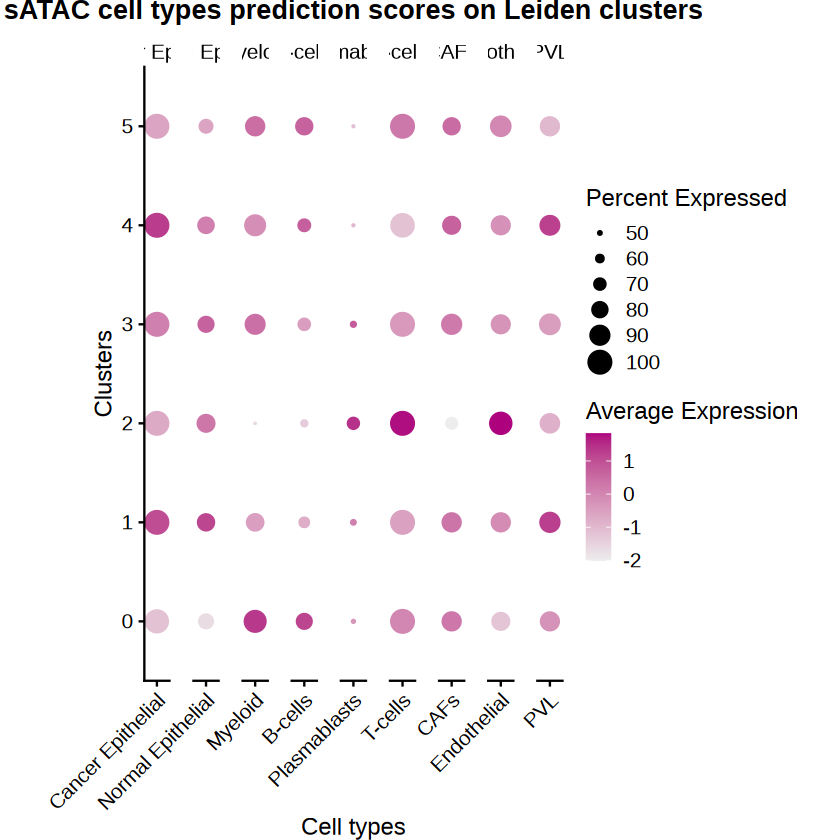

In [ ]:
# Now plot
DotPlot(satac_selected, features = prediction_features, cols = c("gray93", "#AE017E")) +
  scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
  scale_y_discrete(name = "Clusters") +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.margin = margin(0, 1, 0, 2, "cm")  # bottom margin extended
  ) +
  ggtitle("sATAC cell type prediction scores on Leiden clusters")
ggsave("dotplot_predictions_leiden_clusters_satac_selected.png", width = 8, height = 5, units = "in", dpi = 300)

In [ ]:
satac_selected@meta.data$

In [ ]:
# Now plot
DotPlot(satac_selected, features = prediction_features, group.by = "kmeans_6", cols = c("gray93", "#AE017E")) +
  scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
  scale_y_discrete(name = "Clusters") +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.margin = margin(0, 1, 0, 2, "cm")  # bottom margin extended
  ) +
  ggtitle("sATAC cell type prediction scores on 6 K-Means clusters")
ggsave("dotplot_predictions_6kmeans_clusters_satac_selected.png", width = 8, height = 5, units = "in", dpi = 300)

ERROR: [1m[33mError[39m in `object[[group.by, drop = TRUE]]`:[22m
[33m![39m 'kmeans_6' not found in this Seurat object
 


In [ ]:

# # save object with the single cell predictions
# saveRDS(satac_selected, "visium_brca_scpredicted.rds")
# saveRDS(combined, "atac_brca_scpredicted.rds")

In [ ]:
# 100 um
# visium
PATH_TO_IMAGE_CLUSTERING_VISIUM_6_KMEANS_ORIGINAL_WSI_100um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv"
PATH_TO_IMAGE_CLUSTERING_VISIUM_LEIDEN_ORIGINAL_WSI_100um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv"
PATH_TO_IMAGE_CLUSTERING_VISIUM_6_KMEANS_fromWSI_MACENKO_100um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_fromWSI_histomicsTK_macenko_nomasking.csv"
PATH_TO_IMAGE_CLUSTERING_VISIUM_LEIDEN_fromWSI_MACENKO_100um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_fromWSI_histomicsTK_macenko_nomasking.csv"
# sATAC
PATH_TO_IMAGE_CLUSTERING_sATAC_6_KMEANS_ORIGINAL_WSI_100um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv"
PATH_TO_IMAGE_CLUSTERING_sATAC_LEIDEN_ORIGINAL_WSI_100um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv"
PATH_TO_IMAGE_CLUSTERING_sATAC_6_KMEANS_fromWSI_MACENKO_100um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_fromWSI_histomicsTK_macenko_nomasking.csv"
PATH_TO_IMAGE_CLUSTERING_sATAC_LEIDEN_fromWSI_MACENKO_100um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_fromWSI_histomicsTK_macenko_nomasking.csv"

# 68 um
# visium
PATH_TO_IMAGE_CLUSTERING_VISIUM_6_KMEANS_ORIGINAL_WSI_68um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv"
PATH_TO_IMAGE_CLUSTERING_VISIUM_LEIDEN_ORIGINAL_WSI_68um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv"
PATH_TO_IMAGE_CLUSTERING_VISIUM_6_KMEANS_fromWSI_MACENKO_68um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_fromWSI_histomicsTK_macenko_nomasking.csv"
PATH_TO_IMAGE_CLUSTERING_VISIUM_LEIDEN_fromWSI_MACENKO_68um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_fromWSI_histomicsTK_macenko_nomasking.csv"
# sATAC
PATH_TO_IMAGE_CLUSTERING_sATAC_6_KMEANS_ORIGINAL_WSI_68um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv"
PATH_TO_IMAGE_CLUSTERING_sATAC_LEIDEN_ORIGINAL_WSI_68um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv"
PATH_TO_IMAGE_CLUSTERING_sATAC_6_KMEANS_fromWSI_MACENKO_68um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_fromWSI_histomicsTK_macenko_nomasking.csv"
PATH_TO_IMAGE_CLUSTERING_sATAC_LEIDEN_fromWSI_MACENKO_68um <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_fromWSI_histomicsTK_macenko_nomasking.csv"